In [1]:
"""
SpaCross Benchmarking Framework -- RCC_TLS_10x (Juno HPC)
=========================================================
Runs SpaCross on RCC TLS 10x Visium samples and saves results in parquet format.

Dataset:
    RCC_TLS_10x: Tertiary Lymphoid Structures in Renal Cell Cancer

Dataset citation:
    Meylan, M., Petitprez, F., Becht, E. et al.
    Tertiary lymphoid structures generate and propagate anti-tumor
    antibody-producing plasma cells in renal cell cancer.
    Immunity 55, 527–541.e5 (2022).

Ground-truth annotations:
    No TLS / TLS / T-cell aggregate (T_agg)
"""

'\nSpaCross Benchmarking Framework -- RCC_TLS_10x (Juno HPC)\n=========================================================\nRuns SpaCross on RCC TLS 10x Visium samples and saves results in parquet format.\n\nDataset:\n    RCC_TLS_10x: Tertiary Lymphoid Structures in Renal Cell Cancer\n\nDataset citation:\n    Meylan, M., Petitprez, F., Becht, E. et al.\n    Tertiary lymphoid structures generate and propagate anti-tumor\n    antibody-producing plasma cells in renal cell cancer.\n    Immunity 55, 527–541.e5 (2022).\n\nGround-truth annotations:\n    No TLS / TLS / T-cell aggregate (T_agg)\n'

# Imports

In [2]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA


# USER CONFIGURATION -- edit these to match your environment

In [ ]:
# =============================================================================
# USER CONFIGURATION -- edit these to match your environment
# =============================================================================
SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data")

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/rcc_tls_spacross")

# Use existing SpaCross config
CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

ALL_RCC_TLS_SAMPLES = [
    "GSM5924042_frozen_a_1",
    "GSM5924043_frozen_a_3",
    "GSM5924044_frozen_a_15",
    "GSM5924045_frozen_a_17",
    "GSM5924046_frozen_b_1",
    "GSM5924047_frozen_b_7",
    "GSM5924048_frozen_b_13",
    "GSM5924049_frozen_b_18",
    "GSM5924031_ffpe_c_3",
    "GSM5924032_ffpe_c_4",
    "GSM5924051_frozen_c_5",
    "GSM5924033_ffpe_c_7",
    "GSM5924035_ffpe_c_20",
    "GSM5924036_ffpe_c_21",
    "GSM5924052_frozen_c_23",
    "GSM5924037_ffpe_c_34",
    "GSM5924038_ffpe_c_36",
    "GSM5924039_ffpe_c_39",
    "GSM5924040_ffpe_c_45",
    "GSM5924041_ffpe_c_51",
    "GSM5924053_frozen_c_57",
    "GSM5924030_ffpe_c_2",
    "GSM5924050_frozen_c_2",
]

SAMPLES_TO_RUN = "all"

METHOD_NAME = "SpaCross"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

GT_LABEL_COL = "z"
SPATIAL_KEY = "S"

# RCC_TLS observed classes per sample
RCC_NUM_CLUSTERS = 3


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


# =============================================================================
# Logging setup
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


# =============================================================================
# Helpers
# =============================================================================
def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_RCC_TLS_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

# Data loading  (RCC_TLS-specific)

In [4]:
# =============================================================================
# Data loading  (RCC_TLS-specific)
# =============================================================================
def load_rcc_tls_sample(config: dict, sample_id: str, tools_mod):
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    # ---- Ground truth ----
    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )

    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)

    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])

    num_clusters = RCC_NUM_CLUSTERS

    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}' "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )

    # ---- Spatial coords ----
    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )

    logging.info(
        f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}"
    )

    # ---- Build k-NN spatial graph ----
    # IMPORTANT:
    # Keep SpaCross graph_construction output unchanged.
    # Do NOT manually convert to COO or dense here.
    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)

    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
    if isinstance(edge_index, torch.Tensor):
        logging.info(f"  [DIAG] graph shape: {tuple(edge_index.shape)}")
        logging.info(f"  [DIAG] graph is_sparse: {edge_index.is_sparse}")

    # ---- Preprocessing ----
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)

    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)

    top_g = min(config["data"]["top_genes"], adata.n_vars)

    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=top_g,
    )

    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )

    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=42,
    ).fit_transform(adata.X)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, edge_index, num_clusters

# Training + metrics for one sample

In [ ]:
# =============================================================================
# Training + metrics for one sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    edge_index,
    num_clusters: int,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    logging.info(
        f"  [TRAIN] Starting SpaCross | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )

    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )

    adata.obs[clust_method] = pred_labels

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]

    ARI, ACC, DIS = tools_mod.get_metrics(
        sub_adata,
        "layer_guess",
        clust_method,
    )

    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "NMI": float(NMI),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
        "dataset": "RCC_TLS_10x",
    }

    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "dataset": "RCC_TLS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })

    return metrics, pred_df

: 

# Main benchmark loop

In [ ]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross RCC_TLS_10x Benchmarking Framework")
    logging.info("=" * 72)

    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}"
        )

    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS

    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    config["data"]["dataset"] = "RCC_TLS_10x"

    logging.info(f"[CONFIG] {config}")

    samples = resolve_samples(SAMPLES_TO_RUN)

    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  num_runs={NUM_RUNS}"
    )

    all_metrics = []
    all_predictions = []
    failed = []
    skipped = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Sample {sample_id}")
        logging.info("-" * 72)

        try:
            result = load_rcc_tls_sample(config, sample_id, TOOLS)

            if result[0] is None:
                skipped.append(sample_id)
                continue

            adata, edge_index, num_clusters = result

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                adata_run = adata.copy()

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    num_clusters=num_clusters,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            continue

    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        logging.warning(f"Skipped samples: {skipped}")
        logging.warning(f"Failed samples: {failed}")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "dataset", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
    ]

    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = [
        "method", "dataset", "sample", "run_seed",
        "spot_id", "true_label", "pred_label",
    ]

    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)

    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )

    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info(
        "\n" + performance[
            ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
        ].to_string(index=False)
    )

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )

    if skipped:
        logging.warning(f"\nSkipped {len(skipped)} sample(s) with <2 classes:")
        for s in skipped:
            logging.warning(f"  - {s}")

    if failed:
        logging.warning(f"\n{len(failed)} sample(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


if __name__ == "__main__":
    run_benchmark()

2026-05-11 15:06:04,375 [INFO] Log file: /home/dal875013/work/projects/mocha/results/rcc_tls_spacross/benchmark.log
2026-05-11 15:06:04,376 [INFO] ========================================================================
2026-05-11 15:06:04,376 [INFO] SpaCross RCC_TLS_10x Benchmarking Framework
2026-05-11 15:06:04,377 [INFO] ========================================================================


2026-05-11 15:06:09,640 [INFO] cffi mode is CFFI_MODE.ANY
2026-05-11 15:06:09,775 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-05-11 15:06:11,096 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-05-11 15:06:11,098 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-05-11 15:06:11,139 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-05-11 15:06:11,819 [INFO] R is already initialized. No need to initialize.
2026-05-11 15:06:13,918 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-05-11 15:06:13,955 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-05-11 15:06:13,957 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-05-11 15:06:13,963 [INFO] [PATHS] SPACROSS_ROOT = /work/dal875013/projects/mocha/methods/spacross/SpaCross
2026-05-11 15:06:13,965 [INFO] [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data
2026-05-11 15:06:13,969 [INFO] [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/result

Epoch 299 total loss=1.472 recon loss=0.871 mean loss=0.427 tri loss=1.369: 100%|██████████| 300/300 [00:12<00:00, 23.19it/s]


2026-05-11 15:06:32,237 [INFO]   [DIAG] Latent shape: (1451, 16)  Recon shape: (1451, 200)
[DEBUG mclust] emb shape = (1451, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 15:06:39,298 [INFO]   [DIAG] Cluster sizes: {'2': 927, '3': 401, '1': 123}
2026-05-11 15:06:39,328 [INFO]   [METRICS] ARI=0.0000  NMI=0.0000  ACC=0.3333  DIS=0.0481  time=21.0s  gpu=NVIDIA A30
2026-05-11 15:06:39,343 [INFO] 
2026-05-11 15:06:39,349 [INFO] ------------------------------------------------------------------------
2026-05-11 15:06:39,350 [INFO] [2/23] Sample GSM5924043_frozen_a_3
2026-05-11 15:06:39,351 [INFO] ------------------------------------------------------------------------
2026-05-11 15:06:39,351 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data/SCE_GSM5924043_frozen_a_3.h5ad
2026-05-11 15:06:39,796 [INFO]   [DIAG] Loaded AnnData: n_obs=1310, n_vars=36601
2026-05-11 15:06:39,807 [INFO]   [DIAG] obs c

Epoch 299 total loss=1.557 recon loss=1.006 mean loss=0.442 tri loss=1.369: 100%|██████████| 300/300 [00:12<00:00, 24.68it/s]

...

2026-05-11 15:08:49,011 [INFO]   [DIAG] Latent shape: (1678, 16)  Recon shape: (1678, 200)


[DEBUG mclust] emb shape = (1678, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 15:08:52,202 [INFO]   [DIAG] Cluster sizes: {'1': 956, '2': 688, '3': 34}
2026-05-11 15:08:52,478 [INFO]   [METRICS] ARI=0.0000  NMI=0.0000  ACC=0.3333  DIS=0.0286  time=9.5s  gpu=NVIDIA A30
2026-05-11 15:08:52,482 [INFO] 
2026-05-11 15:08:52,482 [INFO] ------------------------------------------------------------------------
2026-05-11 15:08:52,483 [INFO] [8/23] Sample GSM5924049_frozen_b_18
2026-05-11 15:08:52,484 [INFO] ------------------------------------------------------------------------
2026-05-11 15:08:52,484 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data/SCE_GSM5924049_frozen_b_18.h5ad
2026-05-11 15:08:53,457 [INFO]   [DIAG] Loaded AnnData: n_obs=1186, n_vars=36601
2026-05-11 15:08:53,458 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 15:08:53,459 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-11 15:08:5

Epoch 299 total loss=1.453 recon loss=0.847 mean loss=0.412 tri loss=1.368: 100%|██████████| 300/300 [00:05<00:00, 53.64it/s]

2026-05-11 15:09:00,539 [INFO]   [DIAG] Latent shape: (1186, 16)  Recon shape: (1186, 200)


[DEBUG mclust] emb shape = (1186, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 15:09:01,783 [INFO]   [DIAG] Cluster sizes: {'1': 847, '2': 239, '3': 100}
2026-05-11 15:09:01,793 [INFO]   [METRICS] ARI=0.0000  NMI=0.0000  ACC=0.3333  DIS=0.2341  time=6.9s  gpu=NVIDIA A30
2026-05-11 15:09:01,796 [INFO] 
2026-05-11 15:09:01,797 [INFO] ------------------------------------------------------------------------
2026-05-11 15:09:01,797 [INFO] [9/23] Sample GSM5924031_ffpe_c_3
2026-05-11 15:09:01,798 [INFO] ------------------------------------------------------------------------
2026-05-11 15:09:01,799 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data/SCE_GSM5924031_ffpe_c_3.h5ad
2026-05-11 15:09:03,887 [INFO]   [DIAG] Loaded AnnData: n_obs=4755, n_vars=17943
2026-05-11 15:09:03,888 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 15:09:03,889 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-11 15:09:03,891

# prediction results visulization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = GSM5924032_ffpe_c_4
n spots in adata      : 3829
n predictions matched : 3829


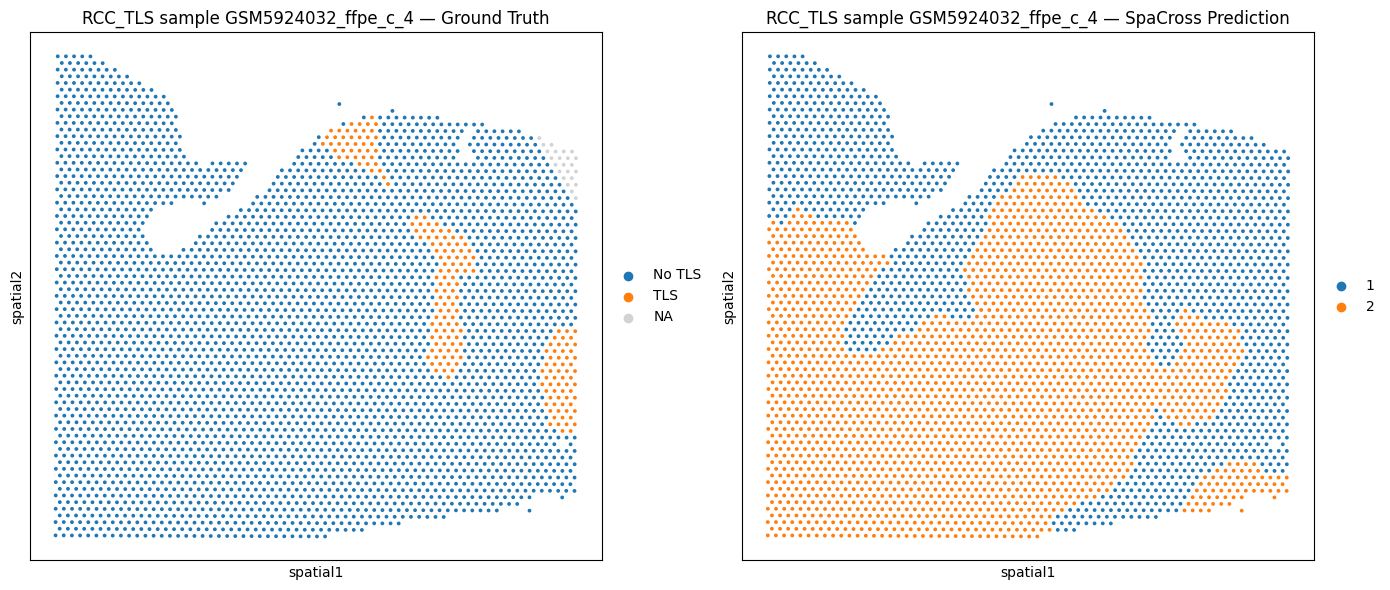

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/rcc_tls_spacross")

# Use one valid RCC_TLS sample ID from performance.parquet
# GSM5924032_ffpe_c_4
SAMPLE_ID = "GSM5924032_ffpe_c_4"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample {SAMPLE_ID}. "
        f"Available samples: {available}"
    )

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"RCC_TLS sample {SAMPLE_ID} — Ground Truth",
    s=30,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"RCC_TLS sample {SAMPLE_ID} — SpaCross Prediction",
    s=30,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/rcc_tls_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "dataset", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model",
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All RCC_TLS SpaCross results =====")
display(performance[display_cols])

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All RCC_TLS SpaCross results =====


,dataset,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,RCC_TLS_10x,GSM5924030_ffpe_c_2,0,-0.040367,0.013983,0.016180,0.025797,2,4510,4509,13.30,mclust,NVIDIA A30
1,RCC_TLS_10x,GSM5924031_ffpe_c_3,0,0.116960,0.050331,0.068094,0.026545,2,4755,4755,13.96,mclust,NVIDIA A30
2,RCC_TLS_10x,GSM5924032_ffpe_c_4,0,0.038889,0.072561,0.092256,0.030092,2,3829,3806,13.24,mclust,NVIDIA A30
3,RCC_TLS_10x,GSM5924033_ffpe_c_7,0,0.054982,0.066326,0.104417,0.027473,2,4975,4975,15.87,mclust,NVIDIA A30
4,RCC_TLS_10x,GSM5924035_ffpe_c_20,0,-0.022423,0.004975,0.005004,0.026124,2,4948,4948,14.36,mclust,NVIDIA A30
5,RCC_TLS_10x,GSM5924036_ffpe_c_21,0,1.000000,1.000000,1.000000,0.025964,1,4915,4915,10.38,mclust,NVIDIA A30
6,RCC_TLS_10x,GSM5924037_ffpe_c_34,0,-0.022920,0.005090,0.005093,0.028982,2,3585,3585,12.03,mclust,NVIDIA A30
7,RCC_TLS_10x,GSM5924038_ffpe_c_36,0,-0.076799,0.029382,0.029522,0.030808,2,3206,3206,12.19,mclust,NVIDIA A30
8,RCC_TLS_10x,GSM5924039_ffpe_c_39,0,-0.005342,0.001022,0.001385,0.026076,2,4940,4940,14.10,mclust,NVIDIA A30
9,RCC_TLS_10x,GSM5924040_ffpe_c_45,0,-0.008032,0.002257,0.004530,0.027069,2,4562,4562,13.59,mclust,NVIDIA A30



===== Mean metrics =====
Mean ARI: 0.2606
Mean NMI: 0.2906
Mean ACC: 0.2978
Mean DIS: 0.0547

===== Best / worst ARI =====
Best ARI : GSM5924036_ffpe_c_21  ARI=1.0000
Worst ARI: GSM5924038_ffpe_c_36  ARI=-0.0768


In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/rcc_tls_spacross")

pred_path = OUTPUT_DIR / "predictions.parquet"

if not pred_path.exists():
    raise FileNotFoundError(f"Cannot find {pred_path}")

predictions = pd.read_parquet(pred_path)

print("===== First 5 rows =====")
display(predictions.head())

print("\n===== Columns =====")
print(list(predictions.columns))

print("\n===== Shape =====")
print(predictions.shape)

print("\n===== dtypes =====")
print(predictions.dtypes)

===== First 5 rows =====


,method,dataset,sample,run_seed,spot_id,true_label,pred_label
0,SpaCross,RCC_TLS_10x,GSM5924042_frozen_a_1,0,AAACAAGTATCTCCCA-1,None,1
1,SpaCross,RCC_TLS_10x,GSM5924042_frozen_a_1,0,AAACAGAGCGACTCCT-1,None,1
2,SpaCross,RCC_TLS_10x,GSM5924042_frozen_a_1,0,AAACGAAGAACATACC-1,None,1
3,SpaCross,RCC_TLS_10x,GSM5924042_frozen_a_1,0,AAACGAGACGGTTGAT-1,None,1
4,SpaCross,RCC_TLS_10x,GSM5924042_frozen_a_1,0,AAACTAACGTGGCGAC-1,None,1



===== Columns =====
['method', 'dataset', 'sample', 'run_seed', 'spot_id', 'true_label', 'pred_label']

===== Shape =====
(68512, 7)

===== dtypes =====
method        object
dataset       object
sample        object
run_seed       int64
spot_id       object
true_label    object
pred_label    object
dtype: object


# actual layer in ground truth checking

In [ ]:
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/RCC_TLS_10x/data")

ALL_RCC_TLS_SAMPLES = [
    "GSM5924042_frozen_a_1",
    "GSM5924043_frozen_a_3",
    "GSM5924044_frozen_a_15",
    "GSM5924045_frozen_a_17",
    "GSM5924046_frozen_b_1",
    "GSM5924047_frozen_b_7",
    "GSM5924048_frozen_b_13",
    "GSM5924049_frozen_b_18",
    "GSM5924031_ffpe_c_3",
    "GSM5924032_ffpe_c_4",
    "GSM5924051_frozen_c_5",
    "GSM5924033_ffpe_c_7",
    "GSM5924035_ffpe_c_20",
    "GSM5924036_ffpe_c_21",
    "GSM5924052_frozen_c_23",
    "GSM5924037_ffpe_c_34",
    "GSM5924038_ffpe_c_36",
    "GSM5924039_ffpe_c_39",
    "GSM5924040_ffpe_c_45",
    "GSM5924041_ffpe_c_51",
    "GSM5924053_frozen_c_57",
    "GSM5924030_ffpe_c_2",
    "GSM5924050_frozen_c_2",
]

results = []

for sample_id in ALL_RCC_TLS_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}")
        continue

    labels = adata.obs["z"]

    # 去掉 NaN
    labels = labels.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
    })

# 转成 dataframe
df = pd.DataFrame(results).sort_values("n_classes")

print("===== Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

===== Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled
0,GSM5924042_frozen_a_1,1,[T_agg],1451,27
3,GSM5924045_frozen_a_17,1,[T_agg],1696,22
6,GSM5924048_frozen_b_13,1,[No TLS],1678,1678
5,GSM5924047_frozen_b_7,1,[T_agg],2374,111
7,GSM5924049_frozen_b_18,1,[TLS],1186,78
13,GSM5924036_ffpe_c_21,1,[No TLS],4915,4915
2,GSM5924044_frozen_a_15,2,"[No TLS, TLS]",1264,1264
1,GSM5924043_frozen_a_3,2,"[No TLS, TLS]",1310,1310
4,GSM5924046_frozen_b_1,2,"[No TLS, TLS]",1949,1949
8,GSM5924031_ffpe_c_3,2,"[No TLS, TLS]",4755,4755



===== Summary =====
n_classes
1     6
2    17
Name: count, dtype: int64

===== Samples with only 1 class =====
['GSM5924042_frozen_a_1', 'GSM5924045_frozen_a_17', 'GSM5924048_frozen_b_13', 'GSM5924047_frozen_b_7', 'GSM5924049_frozen_b_18', 'GSM5924036_ffpe_c_21']
